# Comparing the Criterion Value
## Original Model vs Phi Specified Model 
### Education Level 1

## Dependencies, Packages & Roots

### Magics

In [1]:
%reload_ext autoreload
%autoreload 2

### Project Paths

In [2]:
from pathlib import Path
import sys
import importlib

# Change this depending on notebook location:
# 0 = notebook is 1 folder inside project root, e.g. dp_termpaper/edu1
# 1 = notebook is 2 folders inside project root, e.g. dp_termpaper/data/moments
# 2 = notebook is 3 folders inside project root
amount_of_levels = 0

DIR = Path.cwd().resolve().parents[amount_of_levels]

if str(DIR) not in sys.path:
    sys.path.insert(0, str(DIR))

import project_paths as pp
from project_imports import *

importlib.reload(pp)
jax.config.update("jax_enable_x64", True)

## Load Data 

In [3]:
###############################################################
#### Define which education level you want to estimate for ####
###############################################################

education_level_file = pp.MOMENTS_DIR / "moments_udd1.txt"
# education_level_file = pp.MOMENTS_DIR / "moments_udd2.txt"
# education_level_file = pp.MOMENTS_DIR / "moments_udd3.txt"

version = "phi_udd1" # for saving results, change this when you change the specification

MORTALITY = pp.DATA_DIR / "mortality.xlsx"

beta0, beta1, beta2 = np.loadtxt(pp.FIRST_STAGE_RESULTS_DIR / "wage_params_udd1_ols.txt")

In [4]:
# Read CSV
df_edu = pd.read_csv(education_level_file)
# read mortality and discard seoncd and third column
df_mort = pd.read_excel(MORTALITY, sheet_name="DOD", usecols=[0, 3])

# 2) standardize colomn name and remove _FREQ_ column
# Iterate over DataFrames (if there are multiple DataFrames to process)
for data_frame in [df_edu]:
    # Rename ALDER → age
    if "ALDER" in data_frame.columns:
        data_frame.rename(columns={"ALDER": "age"}, inplace=True)
    # Remove _FREQ_-column if it exists
    # if "_FREQ_" in data_frame.columns:
    #     data_frame.drop(columns=["_FREQ_"], inplace=True)
# drop var_wage, skew_wage and pens
df_edu.drop(columns=["var_wage", "skew_wage", "pens"], inplace=True)
# df_edu

# ====================================================================================================================

## Options for model - Choices and states

In [5]:
n_periods = 55
labour_choices = np.arange(5) # 5 choices
alpha1, alpha2 = np.loadtxt(pp.STRUCTURAL_RESULTS_DIR/ "mortality_params.txt")

model_config = {
    "n_periods": n_periods,
    "choices": labour_choices, # 5 choices
    "n_quad_points": 5,
    "continuous_states": {
        "assets_end_of_period": np.linspace(0, 50, 20),
        "experience": jnp.linspace(0, 1, 5).astype(float) # 1 experince grid point, if experience can only go up by a year - more points if it is a fraction based on hours worked
        },
    "stochastic_states": {
        "survival": [0, 1],
    }
    }

model_specs = {
    "choices": labour_choices, # 5 choices
    "n_periods": n_periods,
    "labour_choices": labour_choices, # 5 choices
    "hours": jnp.array([0,250,750,1300,1900]), #list 
    "max_hours": 1900,
    "start_age": 30,
    "tax_threshold1": 0.480,
    "tax_threshold2": 5.698,
    "tax_base_rate": 0.38,
    "tax_top_rate": 0.5,
    "retirement_age": 67,
    "oap_base_amount": 0.80328,
    "oap_max_supplement": 0.92940,
    "supp_threshold": 0.79300,
    "oap_threshold": 3.3592,
    "supp_reduction_rate": 0.309,
    "oap_reduction_rate": 0.3,
    "alpha1": alpha1, # independently estimated parameter for survival probability
    "alpha2": alpha2,  # independently estimated parameter for survival probability
    "max_init_experience": 5,
    "max_ret_period": 45, # Age 75
    "min_ret_period": 30, # Age 60
}
stochastic_states_transitions = {
    "survival": prob_survival
}

### Initial values for simulating. 

In [6]:
# Select number of individuals for simulation
#Debug level
n_individuals = 10000

# Optimal level
# n_individuals = 250000

seed = 132
key = jax.random.PRNGKey(0)
n = n_individuals       

# hours mapping for simulation
hours_map = {0: 0, 1: 250, 2: 750, 3: 1300, 4: 1900}

#age for simulation
start_age = model_specs["start_age"] 

# distribution of initial choices
labels = jnp.array([0, 1, 2, 3, 4], dtype=jnp.int32)
probs  = jnp.array([0.259155, 0.118310, 0.108099, 0.108451, 0.405986])  # sums to 1.0

lagged_choice = jax.random.choice(
    key,
    a       = labels,
    shape   = (n,),
    p       = probs,
    replace = True
)

# set initial states for each individual
states_initial = {
    "period": jnp.zeros(n_individuals, dtype=jnp.int32),      # Every individual starts at period 0 (age 30)
    "lagged_choice": lagged_choice,  # Every individual starts with choice 3 (work fulltime)
    "experience": jnp.full(n_individuals, 1).astype(float),  # Every individual starts with 5 years of experience
    "survival": jnp.ones(n_individuals, dtype=jnp.int32), # Every individual starts with 1 (alive)
    "assets_begin_of_period": jnp.full(n_individuals, 0.505047) # Every individual starts with 59k wealth - to be adjusted based on the actual moments
}

### Define Criterion function for simulating across seeds

In [ ]:
def criterion(model_solved, seed=seed):
    
    keep_cols = ["hours_0", "hours_1","hours_2","hours_3","hours_4", "work_work", "nowork_nowork"]

    # Simulate model
    sim = model_solved.simulate(
        states_initial=states_initial,
        seed=seed,
    )

    # Compute simulated moments - returning a dataframe similar to the actual data
    sim_moments = compute_simulation_moments(sim, start_age, hours_map)
    empirical_moms = df_edu.copy()  # Your empirical moments DataFrame

    # Drop the "pens" column from both simulated and empirical moments if present
    if "pens" in sim_moments.columns:
        sim_moments = sim_moments.drop(columns=["pens"])
    if "pens" in empirical_moms.columns:
        empirical_moms = empirical_moms.drop(columns=["pens"])

    # Select only the columns of interest for the moments comparison
    sim_moments = sim_moments[keep_cols]
    empirical_moms = empirical_moms[keep_cols]

    # Convert DataFrames to numpy arrays.
    # They should have the same shape, e.g., (num_ages, num_moments)
    sim_vals = sim_moments.to_numpy()
    emp_vals = empirical_moms.to_numpy()

    # Debug-print shapes so that we can ensure they are the same shape
    print("Simulated moments shape:", sim_vals.shape)
    print("Empirical moments shape:", emp_vals.shape)

    # Compute the difference between simulated and empirical moments.
    # diff will have shape (num_ages, num_moments)
    diff = sim_vals - emp_vals

    # Now, for each moment (each column), compute the sample variance of the empirical moment
    ## Should be computed through the data before moments i think
    emp_var = np.nanvar(emp_vals, axis=0, ddof=1)  # Sample variance
    # compute simulated moments variance
    sim_var = np.nanvar(sim_vals, axis=0, ddof=1)  # Sample variance

    # Set a small epsilon to avoid division by zero.
    epsilon = 1e-10

    # The weight for each moment is defined as 1/(variance + epsilon).
    weights = 1.0 / (emp_var + epsilon)
  
    # Instead of forming a full weighting matrix, we can compute the objective by summing over moment columns.
    # For each moment i, compute the sum of squared differences over ages, multiplied by its weight.
    # as in crit = diff^T * W * diff
    # where W is a diagonal matrix with weights on the diagonal.
    # The crit_val is the sum of the weighted squared differences.
    
    num_moments = diff.shape[1]
    crit_val = 0.0
    for i in range(num_moments):
        crit_val += weights[i] * np.nansum(diff[:, i] ** 2)
    
    print("Seed:", seed)
    print("Crit value:", crit_val)
    return float(crit_val)

## New model

### Load params, solve model and simulate juts once

In [8]:
params = load_params_txt(pp.STRUCTURAL_RESULTS_DIR / f"optimized_params_phi_udd1.txt")
# If you want to see Frederiks original parameters, load optimized_params_udd1.txt instead
params["gamma"] = jnp.asarray(params["gamma"])

In [9]:
new_model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=utility_functions,
    utility_functions_final_period=final_period_utility,
    budget_constraint=budget_dcegm_initial,
    state_space_functions=create_state_space_function_dict(),
    stochastic_states_transitions=stochastic_states_transitions,
)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  25
Model setup complete.



In [10]:
new_model_solved = new_model.solve(params)
new_model.validate_exogenous(params)

True

### Number of simulations used

In [11]:
n_sim = 1000

### Running the criterion value across {n_sim} seeds for my model

In [12]:
new_model_results = []
rng = np.random.default_rng()

for i in range(n_sim):
    seed = int(rng.integers(0, 2**31 - 1))
    crit_val = criterion(new_model_solved, seed)

    print(f"Run {i+1:03d} | Seed: {seed} | Criterion value: {crit_val:.6f}")

    new_model_results.append({
        "seed": seed,
        "criterion_value": crit_val,
    })


new_model_crit_table = pd.DataFrame(new_model_results)

new_model_crit_table

new_model_crit_table.to_csv(
    pp.STRUCTURAL_RESULTS_DIR / "new_model_criterion_by_seed.csv",
    index=False,
)

Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 1525350954
Crit value: 227.36168747899978
Run 001 | Seed: 1525350954 | Criterion value: 227.361687
Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 1106463931
Crit value: 239.24931385849968
Run 002 | Seed: 1106463931 | Criterion value: 239.249314
Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 203635764
Crit value: 240.18799329986538
Run 003 | Seed: 203635764 | Criterion value: 240.187993
Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 1935478679
Crit value: 231.88769320210315
Run 004 | Seed: 1935478679 | Criterion value: 231.887693
Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 396665946
Crit value: 232.03001794562826
Run 005 | Seed: 396665946 | Criterion value: 232.030018
Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 919559033
Crit value: 237.62560311760194
Run 006 | Seed: 919559033 | Criterio

## Old model

### Load params, solve model and simulate juts once

In [13]:
params_old = {
    "interest_rate": 0.01,
    "income_shock_mean": 0.0,
    "income_shock_std": 0.14742102900070453,
    "taste_shock_scale": 1.001115695446512,
    "discount_factor": 0.964563568359607,
    "rho": 0.4454231184249471,
    "gamma": jnp.asarray([0.81221354, 1.49218307, 1.80979585, 1.40354442]),
    "beta0": -6.896104044649039,
    "beta1": 0.027168298835917603,
    "beta2": -0.0001768093349215613,
    "kappa1": 0.013789015903515455,
    "kappa2": 0.0018048522486597738,
    "phi": 1.0775170623683508,
    "alpha1": 0.000417,
    "alpha2": 0.099277,
    "b_scale": 1.1673377830168972,
    "xi": 0.39448163025955474,
    "eta_edu": 0.43848,
}

In [14]:
def flow_util(consumption, choice, params, period, model_specs, lagged_choice):
    # Utility parameter
    rho = params["rho"]

    # Disutility parameters
    age = (model_specs["start_age"] + period).astype(float)
    gamma = params["gamma"][choice - 1]  # remove the first element

    ##############################################
    ########## Disutility of working #############
    ##############################################
    working = choice > 0  # 1 if choice is working, 0 if not
    # -------  Zero disutility from working if unemployed

    # Age component of disutility
    age_linear = jnp.where(age >= 55, params["kappa1"] * (age - 55), 0.0)
    age_quadratic = jnp.where(age >= 55, params["kappa2"] * (age - 55) ** 2, 0.0)   
    # + age_linear

    # estimate total disutility
    disutil_0 = working * (1.0 + age_linear + age_quadratic) * gamma

    # No disutility from working, if you dont work.
    disutil = jnp.where(working, disutil_0, 0.0)  # if working == 0, disutility = 0

    ##############################################
    ############# Transaction costs  #############
    ##############################################

    # transition cost when going from working to unemployed, and vice versa
    trans_cost = jnp.where(
        choice != lagged_choice, params["phi"], 0.0
    )

    # Utility for agents that are alive.
    u = (
        ((consumption ** (1 - rho)) - 1) / (1 - rho) - disutil - trans_cost
    ) 

    return u


def marginal_utility(consumption, params):
    rho = params["rho"]
    u_prime = consumption ** (-rho)
    return u_prime


def inverse_marginal_utility(marginal_utility, params):
    rho = params["rho"]
    return marginal_utility ** (-1 / rho)


utility_functions = {
    "utility": flow_util,
    "inverse_marginal_utility": inverse_marginal_utility,
    "marginal_utility": marginal_utility,
}

In [15]:
old_model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=utility_functions,
    utility_functions_final_period=final_period_utility,
    budget_constraint=budget_dcegm_initial,
    state_space_functions=create_state_space_function_dict(),
    stochastic_states_transitions=stochastic_states_transitions,
)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  25
Model setup complete.



In [16]:
old_model_solved = old_model.solve(params_old)
old_model.validate_exogenous(params_old)

True

### Running the criterion value across 100 seeds for Larsen model

In [17]:
old_model_results = []
rng = np.random.default_rng()

for i in range(n_sim):
    seed = int(rng.integers(0, 2**31 - 1))
    crit_val = criterion(old_model_solved, seed)

    print(f"Run {i+1:03d} | Seed: {seed} | Criterion value: {crit_val:.6f}")

    old_model_results.append({
        "seed": seed,
        "criterion_value": crit_val,
    })

old_model_crit_table = pd.DataFrame(old_model_results)

old_model_crit_table

old_model_crit_table.to_csv(
    pp.STRUCTURAL_RESULTS_DIR / "old_model_criterion_by_seed.csv",
    index=False,
)

Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 334977652
Crit value: 343.10623598173237
Run 001 | Seed: 334977652 | Criterion value: 343.106236
Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 1635004485
Crit value: 341.4979013774513
Run 002 | Seed: 1635004485 | Criterion value: 341.497901
Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 262960959
Crit value: 318.84352412620507
Run 003 | Seed: 262960959 | Criterion value: 318.843524
Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 372255868
Crit value: 332.94228728243115
Run 004 | Seed: 372255868 | Criterion value: 332.942287
Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 671255639
Crit value: 325.4191471990324
Run 005 | Seed: 671255639 | Criterion value: 325.419147
Simulated moments shape: (55, 7)
Empirical moments shape: (55, 7)
Seed: 1916750785
Crit value: 329.9179062173429
Run 006 | Seed: 1916750785 | Criterion val

### Plot the results from both runs

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

old_vals = old_model_crit_table["criterion_value"]
new_vals = new_model_crit_table["criterion_value"]

summary_table = pd.DataFrame({
    "model": ["old", "new"],
    "mean": [old_vals.mean(), new_vals.mean()],
    "median": [old_vals.median(), new_vals.median()],
    "std": [old_vals.std(), new_vals.std()],
    "min": [old_vals.min(), new_vals.min()],
    "max": [old_vals.max(), new_vals.max()],
})

summary_table

,model,mean,median,std,min,max
0,old,335.360557,335.276699,6.639382,312.596302,358.670044
1,new,232.923393,232.937786,5.800836,217.111516,251.493449


In [22]:
# Save values from old and new model for plotting
np.savez(
    pp.COMP_PLOTS_DIR / f"criterion_values_nb1_{n_sim}sim.npz",
    old_vals=old_vals,
    new_vals=new_vals
)

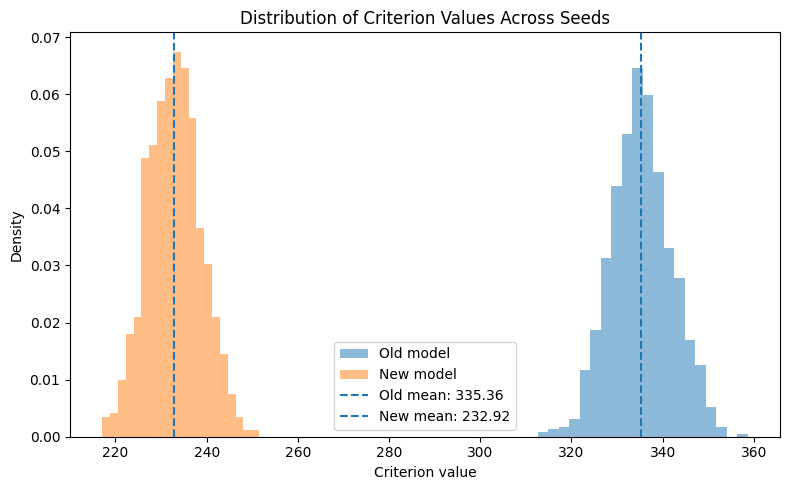

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    old_vals,
    bins=20,
    alpha=0.5,
    density=True,
    label="Old model",
)

plt.hist(
    new_vals,
    bins=20,
    alpha=0.5,
    density=True,
    label="New model",
)

plt.axvline(old_vals.mean(), linestyle="--", label=f"Old mean: {old_vals.mean():.2f}")
plt.axvline(new_vals.mean(), linestyle="--", label=f"New mean: {new_vals.mean():.2f}")

plt.xlabel("Criterion value")
plt.ylabel("Density")
plt.title("Distribution of Criterion Values Across Seeds")
plt.legend()
plt.tight_layout()
plt.show()